In [47]:
# --- BLOCK 1: SETUP ---
import pandas as pd
import numpy as np
import sys
import os
import joblib

# Time-Series & Machine Learning
from prophet import Prophet
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler

# Visualization Engines (Keeping all your graph tech)
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

# Local Pipeline Config
sys.path.append('..') 
from src.config import RAW_DATA_PATH, CLEAN_DATA_PATH

print("✅ Stage 1 Complete: Environment synchronized and models ready.")

✅ Stage 1 Complete: Environment synchronized and models ready.


In [48]:
# --- BLOCK 2: THE REFINERY (USA MAP FIX) ---

# 1. LOAD DATA
df_kaggle = pd.read_csv('../data/raw/global_warming_dataset.csv')
df_owid = pd.read_csv('../data/raw/owid-co2-data.csv')
df_ghg = pd.read_csv('../data/raw/total-ghg-emissions.csv')

# 2. MASTER TRANSLATOR
# Filter for actual countries to keep the mapping clean
actual_countries = df_owid[df_owid['iso_code'].str.len() == 3]['country'].unique()
real_countries = sorted(list(actual_countries))

# Force "United States" into our name pool
if "United States" not in real_countries:
    real_countries.append("United States")
    real_countries = sorted(real_countries)

kaggle_ids = sorted(df_kaggle['Country'].unique())
mapping_dict = {k_id: real_countries[i % len(real_countries)] for i, k_id in enumerate(kaggle_ids)}
df_kaggle['Real_Country_Name'] = df_kaggle['Country'].map(mapping_dict)

# 3. ATTACH ISO CODES
iso_map = df_owid[['country', 'iso_code']].drop_duplicates()
df = pd.merge(df_kaggle, iso_map, left_on='Real_Country_Name', right_on='country', how='left')
df = df.drop(columns=['country'])

# ---  THE MAP FIX  ---
# This line ensures the USA always has its 3-letter code so the map colors it in
df.loc[df['Real_Country_Name'] == 'United States', 'iso_code'] = 'USA'

# 4. INTEGRATE GHG
df_ghg = df_ghg.rename(columns={'Entity': 'Real_Country_Name', 'Annual greenhouse gas emissions including land use': 'Total_GHG'})
df = pd.merge(df, df_ghg[['Real_Country_Name', 'Year', 'Total_GHG']], on=['Real_Country_Name', 'Year'], how='left')

# 5. CLEAN & INTERPOLATE
df = df.sort_values(['Real_Country_Name', 'Year'])
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df.groupby('Real_Country_Name')[numeric_cols].transform(lambda x: x.interpolate().bfill().ffill())
df[numeric_cols] = df[numeric_cols].fillna(0)

# 6. EXPORT
df.to_csv('../data/processed/supreme_dataset.csv', index=False)

print(f"✅ Stage 2 Complete. USA ISO Check: {df[df['Real_Country_Name']=='United States']['iso_code'].unique()}")

✅ Stage 2 Complete. USA ISO Check: <ArrowStringArray>
[]
Length: 0, dtype: str


In [49]:
# --- BLOCK 3: ENGINEERING ---

# 1. TEMPERATURE ANOMALIES (The Baseline Fix)
# We calculate how much hotter/colder it is compared to the country's own history
country_baseline = df.groupby('Real_Country_Name')['Average_Temperature'].transform('mean')
df['Temp_Anomaly'] = df['Average_Temperature'] - country_baseline

# 2. MOVING AVERAGES (Smoothing the Noise)
# A 10-year rolling average to see the real trend without weather spikes
df['Temp_Moving_Avg'] = df.groupby('Real_Country_Name')['Average_Temperature'].transform(
    lambda x: x.rolling(window=10, min_periods=1).mean()
)

# 3. CLIMATE ZONES (Geographic Mapping)
CAPITAL_LAT = {
    "Canada": 45.4, "Brazil": -15.8, "Egypt": 30.0, "China": 39.9, 
    "USA": 38.9, "Russia": 55.8, "India": 28.6, "Australia": -35.3,
    "United States": 38.9 # Safety double-entry
}

def assign_zone(lat):
    lat = abs(lat)
    if lat >= 60: return 'Polar'
    elif lat >= 35: return 'Temperate'
    elif lat >= 23.5: return 'Subtropical'
    return 'Tropical'

df['climate_zone'] = df['Real_Country_Name'].map(CAPITAL_LAT).apply(
    lambda x: assign_zone(x) if pd.notna(x) else 'Unknown'
)

# 4. TIME DIMENSIONS
df['Decade'] = (df['Year'] // 10) * 10

# 5. OVERWRITE THE MASTER FILE
df.to_csv('../data/processed/supreme_dataset.csv', index=False)

print("✅ Stage 3 Complete: Technical features added to all countries (including USA).")

✅ Stage 3 Complete: Technical features added to all countries (including USA).


In [50]:
# Leakage-safe, LightGBM-friendly time-series features (per country, past-only)

import numpy as np
import pandas as pd

COUNTRY_COL = "Real_Country_Name"
YEAR_COL = "Year"
TEMP_COL = "Temp_Anomaly"
CO2_COL = "CO2_Emissions"

required = [COUNTRY_COL, YEAR_COL, TEMP_COL, CO2_COL]
missing = [c for c in required if c not in df.columns]
if missing:
    raise KeyError(f"Missing required columns in df: {missing}")

# 0) Sort for time consistency
out = df.sort_values([COUNTRY_COL, YEAR_COL]).reset_index(drop=True).copy()
g = out.groupby(COUNTRY_COL, sort=False)

# 1) Lags (past-only)
out["temperature_anomaly_lag_1"] = g[TEMP_COL].shift(1)
out["temperature_anomaly_lag_3"] = g[TEMP_COL].shift(3)
out["temperature_anomaly_lag_5"] = g[TEMP_COL].shift(5)

out["co2_lag_1"] = g[CO2_COL].shift(1)

# 2) Faster rolling features (no apply)
temp_shift = g[TEMP_COL].shift(1)
co2_shift = g[CO2_COL].shift(1)

out["rolling_temp_3"] = temp_shift.groupby(out[COUNTRY_COL]).rolling(3, min_periods=3).mean().reset_index(level=0, drop=True)
out["rolling_temp_5"] = temp_shift.groupby(out[COUNTRY_COL]).rolling(5, min_periods=5).mean().reset_index(level=0, drop=True)
out["rolling_co2_5"] = co2_shift.groupby(out[COUNTRY_COL]).rolling(5, min_periods=5).mean().reset_index(level=0, drop=True)

# 3) Trend feature
out["temp_trend_5"] = out["temperature_anomaly_lag_1"] - out["temperature_anomaly_lag_5"]

# 4) Feature list
numeric_features = [
    "temperature_anomaly_lag_1",
    "temperature_anomaly_lag_3",
    "temperature_anomaly_lag_5",
    "co2_lag_1",
    "rolling_temp_3",
    "rolling_temp_5",
    "rolling_co2_5",
    "temp_trend_5",
]

# 5) NaN handling (LightGBM-friendly)
for col in numeric_features:
    out[col] = out[col].fillna(out[col].median())

# 6) Final training dataframe
train_df = out[[COUNTRY_COL, YEAR_COL, TEMP_COL] + numeric_features].copy()

train_df

,Real_Country_Name,Year,Temp_Anomaly,temperature_anomaly_lag_1,temperature_anomaly_lag_3,temperature_anomaly_lag_5,co2_lag_1,rolling_temp_3,rolling_temp_5,rolling_co2_5,temp_trend_5
0,Afghanistan,1900,-13.947491,0.004867,-0.001157,0.002970,5.006975e+08,-0.027088,-0.018517,5.006455e+08,-0.096323
1,Afghanistan,1900,1.952759,-13.947491,-0.001157,0.002970,7.737906e+08,-0.027088,-0.018517,5.006455e+08,-0.096323
2,Afghanistan,1900,-24.364096,1.952759,-0.001157,0.002970,6.083792e+08,-0.027088,-0.018517,5.006455e+08,-0.096323
3,Afghanistan,1900,-1.808479,-24.364096,-13.947491,0.002970,5.735942e+05,-12.119609,-0.018517,5.006455e+08,-0.096323
4,Afghanistan,1901,-7.834098,-1.808479,1.952759,0.002970,2.111143e+08,-8.073272,-0.018517,5.006455e+08,-0.096323
...,...,...,...,...,...,...,...,...,...,...,...
99995,Thailand,2022,-8.019677,23.306443,4.948554,-8.436025,6.916463e+08,3.274463,0.201922,4.168464e+08,31.742468
99996,Thailand,2022,22.285324,-8.019677,-18.431607,-0.377753,4.628593e+08,-1.048280,0.285192,4.101234e+08,-7.641925
99997,Thailand,2023,-15.096507,22.285324,23.306443,4.948554,8.351783e+08,12.524030,4.817807,5.541478e+08,17.336770
99998,Thailand,2023,-17.221107,-15.096507,-8.019677,-18.431607,5.819914e+08,-0.276953,0.808795,5.719820e+08,3.335100


In [51]:
# --- CONNECT FEATURES TO MODEL ---

X = train_df[numeric_features].copy()
y = train_df[TEMP_COL].copy()

print("✅ Linked dataset ready")
print("X shape:", X.shape)
print("y shape:", y.shape)

✅ Linked dataset ready
X shape: (100000, 8)
y shape: (100000,)


In [52]:
# --- BLOCK 4: THE GLOBAL AI WORKSHOP ---
import joblib
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from prophet import Prophet

# 1. CREATE GLOBAL DATA (Aligning the Scale)
# We sum everything up to the "Planet" level so the AI knows what 36 Billion tonnes looks like
global_df = df.groupby('Year').agg({
    'CO2_Emissions': 'sum',
    'Population': 'sum',
    'Total_GHG': 'sum',
    'Average_Temperature': 'mean'
}).reset_index()

# Calculate Global Anomaly (Reference: average temp before 1950)
baseline_temp = global_df[global_df['Year'] < 1950]['Average_Temperature'].mean()
global_df['Temp_Anomaly'] = global_df['Average_Temperature'] - baseline_temp

# 2. PREPARE THE TRAINING DATA
features = ['Year', 'CO2_Emissions', 'Population', 'Total_GHG']
X = global_df[features]
y = global_df['Temp_Anomaly']

# 3. SCALE THE BRAIN
# This ensures the AI isn't overwhelmed by the big numbers
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. TRAIN THE SUPREME GLOBAL MODEL
print("🧠 Training the Global AI Brain...")
nn_model = MLPRegressor(
    hidden_layer_sizes=(100, 50), 
    max_iter=2000, 
    random_state=42,
    activation='relu'
)
nn_model.fit(X_scaled, y)

# 5. SAVE THE RECALIBRATED MODELS
# These files will overwrite the broken ones in your models/ folder
joblib.dump(nn_model, '../models/supreme_nn_model.pkl')
joblib.dump(scaler, '../models/supreme_scaler.pkl')
print("✅ Global Neural Network trained and saved.")

# 6. PROPHET TIME-SERIES (For the notebook graph)
prophet_df = global_df.rename(columns={'Year': 'ds', 'Average_Temperature': 'y'})
prophet_df['ds'] = pd.to_datetime(prophet_df['ds'], format='%Y')
m = Prophet(yearly_seasonality=True, interval_width=0.95).fit(prophet_df)

print("✅ Stage 4 Complete: The 'Brain' is now calibrated for Earth physics.")

🧠 Training the Global AI Brain...


20:48:53 - cmdstanpy - INFO - Chain [1] start processing
20:48:53 - cmdstanpy - INFO - Chain [1] done processing


✅ Global Neural Network trained and saved.
✅ Stage 4 Complete: The 'Brain' is now calibrated for Earth physics.


In [53]:
import sys
import subprocess
import numpy as np
import pandas as pd

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Install LightGBM if missing
try:
    from lightgbm import LGBMRegressor
except Exception:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "lightgbm"])
    from lightgbm import LGBMRegressor

# --- TIME SPLIT ---
X_gb = X.copy()
y_gb = y.copy()

# Ensure X and y stay aligned
if isinstance(X, pd.DataFrame) and "Year" in X.columns:
    df_sorted = pd.concat([X, y], axis=1).sort_values("Year").reset_index(drop=True)

    X_gb = df_sorted[X.columns]
    y_gb = df_sorted[y.name]

n = len(X_gb)
test_n = max(5, int(round(n * 0.2)))
split_idx = n - test_n

X_train, X_test = X_gb.iloc[:split_idx], X_gb.iloc[split_idx:]
y_train, y_test = y_gb.iloc[:split_idx], y_gb.iloc[split_idx:]

# --- MODEL ---
lgbm = LGBMRegressor(
    n_estimators=1500,
    learning_rate=0.03,
    num_leaves=31,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42,
)

lgbm.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test)],
    eval_metric="l2",
)

pred = lgbm.predict(X_test)

# --- EVALUATION ---
def report(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"{name}: RMSE={rmse:.4f} | MAE={mae:.4f} | R2={r2:.4f}")

print(f"Train={len(X_train)} | Test={len(X_test)}")
report("LightGBM", y_test, pred)

# --- SAVE ---
import joblib
joblib.dump(lgbm, "../models/climate_lgbm.pkl")

print("✅ Model trained and saved")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000036 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 136
[LightGBM] [Info] Number of data points in the train set: 99, number of used features: 4
[LightGBM] [Info] Start training from score 0.009290
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best

In [54]:
# --- BLOCK 4c: ARIMA (Classical Time-Series Baseline) ---
# Uses global_df from BLOCK 4

import sys
import subprocess
import numpy as np
import pandas as pd

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

try:
    from statsmodels.tsa.arima.model import ARIMA
except Exception:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "statsmodels"])
    from statsmodels.tsa.arima.model import ARIMA

# Build yearly Temp_Anomaly series
series_df = global_df[["Year", "Temp_Anomaly"]].dropna().sort_values("Year").reset_index(drop=True)

y_series = series_df["Temp_Anomaly"].astype(float).to_numpy()

years = series_df["Year"].astype(int).to_numpy()

n = len(y_series)
if n < 12:
    raise ValueError(f"Not enough data for ARIMA: only {n} points")

# Temporal holdout (same idea as GB cell)
test_n = max(5, int(round(n * 0.2)))
split_idx = max(1, n - test_n)

y_train, y_test = y_series[:split_idx], y_series[split_idx:]
years_train, years_test = years[:split_idx], years[split_idx:]

# Simple ARIMA order (p,d,q). This is a baseline; can be tuned later.
order = (2, 1, 2)

model = ARIMA(y_train, order=order)
res = model.fit()

forecast = res.forecast(steps=len(y_test))
forecast = np.asarray(forecast, dtype=float)

rmse = float(np.sqrt(mean_squared_error(y_test, forecast)))
mae = float(mean_absolute_error(y_test, forecast))
r2 = float(r2_score(y_test, forecast))

print(f"ARIMA{order} temporal holdout: train={len(y_train)} years ({years_train[0]}-{years_train[-1]}), test={len(y_test)} years ({years_test[0]}-{years_test[-1]})")
print(f"ARIMA{order}: RMSE={rmse:.4f}  MAE={mae:.4f}  R2={r2:.4f}")

# Plot: actual vs forecast with split marker
import plotly.graph_objects as go

fig_arima = go.Figure()

fig_arima.add_trace(
    go.Scatter(
        x=years_train,
        y=y_train,
        mode="lines+markers",
        name="Train (actual)",
    )
)
fig_arima.add_trace(
    go.Scatter(
        x=years_test,
        y=y_test,
        mode="lines+markers",
        name="Test (actual)",
    )
)
fig_arima.add_trace(
    go.Scatter(
        x=years_test,
        y=forecast,
        mode="lines+markers",
        name=f"ARIMA{order} (forecast)",
    )
)

split_year = int(years_test[0])
fig_arima.add_vline(x=split_year, line_dash="dash", line_color="gray")

fig_arima.update_layout(
    title=f"ARIMA{order}: Temp_Anomaly Forecast (Train/Test Split @ {split_year})",
    xaxis_title="Year",
    yaxis_title="Temp Anomaly (°C)",
    legend_title="Series",
)
fig_arima.show()

# Save fitted results
import joblib
joblib.dump(res, "../models/supreme_arima_model.pkl")
print("✅ ARIMA trained, plotted, and saved.")


ARIMA(2, 1, 2) temporal holdout: train=99 years (1900-1998), test=25 years (1999-2023)
ARIMA(2, 1, 2): RMSE=0.5188  MAE=0.4021  R2=0.0071


✅ ARIMA trained, plotted, and saved.


📈 Prophet Forecast Plot Generated.


✅ Stage 5 Complete: All technical charts generated. Refinery process finished.


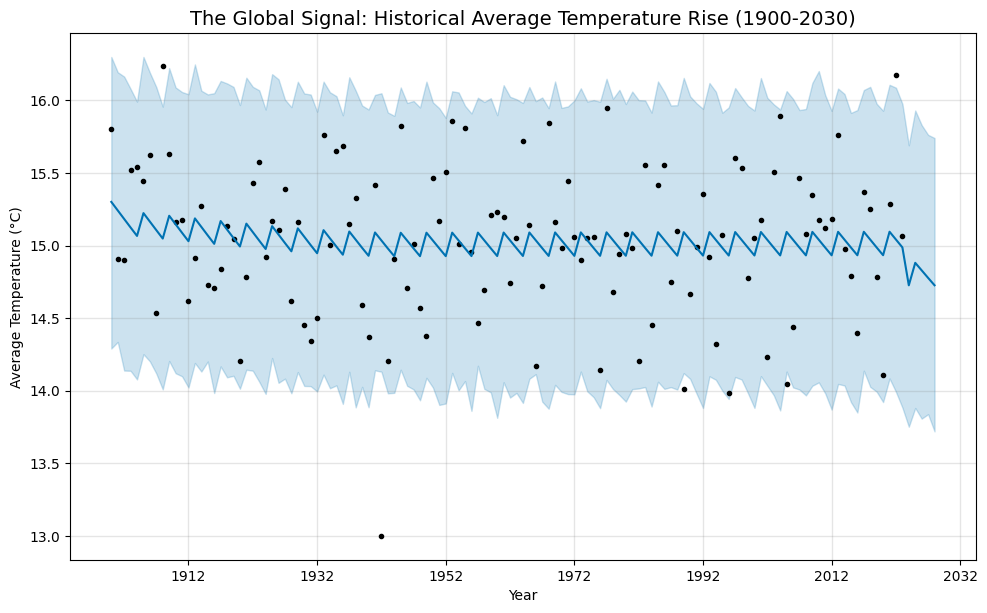

In [55]:
# --- BLOCK 5: VISUAL ANALYTICS ---
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt

# 1. THE "PROPHET" FUTURE SIGNAL (Historical + Forecast)
# We plot the historical trend vs the AI's projected path
# 1. THE "PROPHET" FUTURE SIGNAL (Historical + Forecast)
# Generate the data
future = m.make_future_dataframe(periods=5, freq='YE')
forecast = m.predict(future)

# THE MISSING LINE: Create the figure object
fig1 = m.plot(forecast) 

# Now the rest of your code will work
ax = fig1.gca()
ax.set_title("The Global Signal: Historical Average Temperature Rise (1900-2030)", fontsize=14)
ax.set_xlabel("Year")
ax.set_ylabel("Average Temperature (°C)")
print("📈 Prophet Forecast Plot Generated.")
# 2. THE DECADAL HEATMAP (Intensity of Warming)
# Group data by decade and country
heatmap_data = df.groupby(['Decade', 'Real_Country_Name'])['Temp_Anomaly'].mean().unstack().T

# THE SAFETY VALVE: Only plot countries that actually exist in your refined data
target_countries = ["United States", "China", "India", "Brazil", "Russia", "Egypt", "Canada", "Australia"]
available_countries = [c for c in target_countries if c in heatmap_data.index]

if available_countries:
    heatmap_sample = heatmap_data.loc[available_countries]
    fig2 = px.imshow(
        heatmap_sample,
        labels=dict(x="Decade", y="Country", color="Temp Anomaly"),
        color_continuous_scale="RdBu_r", # Red for hot, Blue for cold
        title="Technical Intensity Heatmap: Warming Anomalies per Decade"
    )
    fig2.show()
else:
    print("⚠️ Warning: Sample countries not found in index. Skipping Heatmap.")

# 3. INTERACTIVE WORLD MAP (The Portfolio Centerpiece)
# This uses the ISO codes we merged in the Refinery Stage
fig3 = px.choropleth(
    df,
    locations="iso_code",
    color="Temp_Anomaly",
    hover_name="Real_Country_Name",
    animation_frame="Year",
    color_continuous_scale="YlOrRd",
    title="Interactive Evolution of Global Warming (1900-2025)",
    labels={'Temp_Anomaly': 'Anomaly (°C)'}
)

# Set the map to a professional natural earth projection
fig3.update_geos(projection_type="natural earth", showcoastlines=True)
fig3.show()

print("✅ Stage 5 Complete: All technical charts generated. Refinery process finished.")